<a href="https://colab.research.google.com/github/rmmartinez015-maker/Capstone-Project/blob/main/ReynaMartinez_PythonAnalysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#importing libraries
import pandas as pd
import numpy as np
!pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

github_url = "https://raw.githubusercontent.com/rmmartinez015-maker/Capstone-Project/refs/heads/main/ca-hcai-total-construction-cost-04162026.csv"

df = pd.read_csv(github_url)

# Display rows
df.head()

,County,Data Generation Date,OSHPD Project Status,Total Costs of OSHPD Projects,Number of OSHPD Projects,Collection of Counties
0,19 - Los Angeles,3/4/2026,In Construction,"$2,995,739,486.36",785.0,Greater Los Angeles Counties
1,19 - Los Angeles,2/20/2026,In Construction,"$2,995,361,069.55",794.0,Greater Los Angeles Counties
2,19 - Los Angeles,3/19/2026,In Construction,"$2,981,974,784.27",786.0,Greater Los Angeles Counties
3,19 - Los Angeles,2/5/2026,In Construction,"$2,980,465,197.10",790.0,Greater Los Angeles Counties
4,19 - Los Angeles,1/22/2026,In Construction,"$2,957,810,136.18",787.0,Greater Los Angeles Counties


In [5]:
# review data set
rows, columns = df.shape
print(f"Total rows: {rows}")
print(f"Total columns: {columns}")

# Data types
print("\nData types:")
df.dtypes

Total rows: 64721
Total columns: 6

Data types:


,0
County,object
Data Generation Date,object
OSHPD Project Status,object
Total Costs of OSHPD Projects,object
Number of OSHPD Projects,float64
Collection of Counties,object


In [6]:
# summary statistics
df.describe(include='all')

,County,Data Generation Date,OSHPD Project Status,Total Costs of OSHPD Projects,Number of OSHPD Projects,Collection of Counties
count,64721,64721,64721,63391,62100.000000,20651
unique,58,327,4,40793,NaN,3
top,19 - Los Angeles,2/13/2015,In Construction,0,NaN,Bay Area Counties
freq,1308,217,17794,1217,NaN,11687
mean,NaN,NaN,NaN,NaN,31.678341,NaN
std,NaN,NaN,NaN,NaN,83.848388,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,3.000000,NaN
50%,NaN,NaN,NaN,NaN,9.000000,NaN
75%,NaN,NaN,NaN,NaN,26.000000,NaN


In [7]:
# Total missing values
total_missing = df.isnull().sum().sum()
print(f"Total missing values in dataset: {total_missing}")

# Missing values by column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percent.round(2)
})

missing_summary

Total missing values in dataset: 48021


,Missing Values,Missing Percentage
Collection of Counties,44070,68.09
Number of OSHPD Projects,2621,4.05
Total Costs of OSHPD Projects,1330,2.05
County,0,0.00
Data Generation Date,0,0.00
OSHPD Project Status,0,0.00


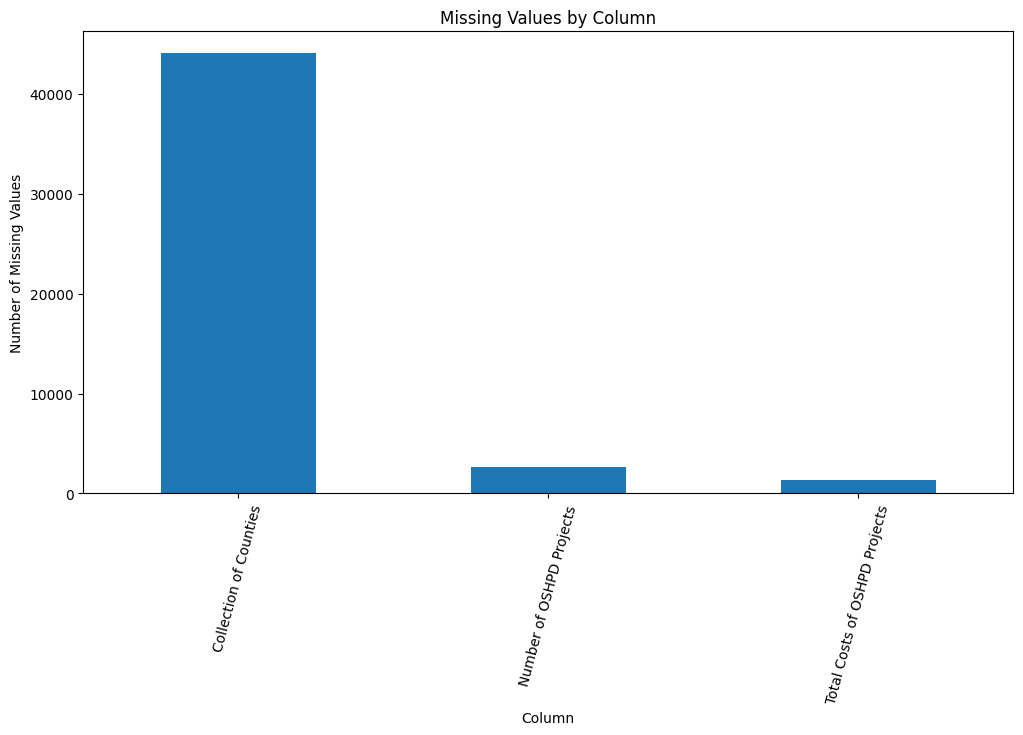

In [8]:
plt.figure(figsize=(12, 6))
missing_summary[missing_summary['Missing Values'] > 0]['Missing Values'].plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=75)
plt.show()

In [62]:
# clean copy of data set
df_clean = df.copy()

# Standardize column names
df_clean.columns = df_clean.columns.str.strip()

df['Total Costs of OSHPD Projects'] = pd.to_numeric(df['Total Costs of OSHPD Projects'].astype(str).str.replace('[$,]', '', regex=True), errors='coerce')

# Convert date columns to datetime
for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Separate columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=[np.number,'datetime64[ns]']).columns.tolist()
datetime_cols = df_clean.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical/text columns:", categorical_cols)
print("Datetime columns:", datetime_cols)

Numeric columns: ['Total Costs of OSHPD Projects', 'Number of OSHPD Projects']
Categorical/text columns: ['County', 'OSHPD Project Status', 'Collection of Counties']
Datetime columns: ['Data Generation Date']


In [19]:
# review data set
rows, columns = df_clean.shape
print(f"Total rows: {rows}")
print(f"Total columns: {columns}")

# Data types
print("\nData types:")
df_clean.dtypes

Total rows: 64721
Total columns: 6

Data types:


,0
County,object
Data Generation Date,datetime64[ns]
OSHPD Project Status,object
Total Costs of OSHPD Projects,float64
Number of OSHPD Projects,float64
Collection of Counties,object


In [20]:
# Impute numeric columns with median
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)

# Impute categorical/text columns with mode; if mode unavailable, use 'Unknown'
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode(dropna=True)
        fill_value = mode_value[0] if len(mode_value) > 0 else 'Unknown'
        df_clean[col].fillna(fill_value, inplace=True)

# Impute datetime columns with mode if available; otherwise use Created Date where appropriate
for col in datetime_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode(dropna=True)
        if len(mode_value) > 0:
            df_clean[col].fillna(mode_value[0], inplace=True)

print("Imputation completed.")

Imputation completed.


/tmp/ipykernel_36540/3817054634.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_value, inplace=True)
/tmp/ipykernel_36540/3817054634.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [21]:
# Verify remaining missing values
remaining_missing = df_clean.isnull().sum().sort_values(ascending=False)
remaining_missing_summary = pd.DataFrame({
    'Remaining Missing Values': remaining_missing,
    'Remaining Missing Percentage': (df_clean.isnull().mean() * 100).round(2)
})

print(f"Total remaining missing values: {df_clean.isnull().sum().sum()}")
remaining_missing_summary

Total remaining missing values: 0


,Remaining Missing Values,Remaining Missing Percentage
County,0,0.0
Data Generation Date,0,0.0
OSHPD Project Status,0,0.0
Total Costs of OSHPD Projects,0,0.0
Number of OSHPD Projects,0,0.0
Collection of Counties,0,0.0


In [22]:
# Final check
if df_clean.isnull().sum().sum() == 0:
    print("The cleaned dataset has no missing values.")
else:
    print("Some missing values remain. Review the summary above.")

The cleaned dataset has no missing values.


In [23]:
# Create useful derived columns for 311 service analysis
if 'Total Costs of OSHPD Projects' in df_clean.columns and 'Number of OSHPD Projects' in df_clean.columns:
    df_clean['Average Project Cost'] = df_clean['Total Costs of OSHPD Projects'] / df_clean['Number of OSHPD Projects']

if 'Data Generation Date' in df_clean.columns:
    df_clean['Created_Month'] = df_clean['Data Generation Date'].dt.month_name()
    df_clean['Created_Day'] = df_clean['Data Generation Date'].dt.day_name()

print("Feature engineering completed.")
df_clean.head()

Feature engineering completed.


,County,Data Generation Date,OSHPD Project Status,Total Costs of OSHPD Projects,Number of OSHPD Projects,Collection of Counties,Average Project Cost,Created_Month,Created_Day
0,19 - Los Angeles,2026-03-04,In Construction,2.995739e+09,785.0,Greater Los Angeles Counties,3.816229e+06,March,Wednesday
1,19 - Los Angeles,2026-02-20,In Construction,2.995361e+09,794.0,Greater Los Angeles Counties,3.772495e+06,February,Friday
2,19 - Los Angeles,2026-03-19,In Construction,2.981975e+09,786.0,Greater Los Angeles Counties,3.793861e+06,March,Thursday
3,19 - Los Angeles,2026-02-05,In Construction,2.980465e+09,790.0,Greater Los Angeles Counties,3.772741e+06,February,Thursday
4,19 - Los Angeles,2026-01-22,In Construction,2.957810e+09,787.0,Greater Los Angeles Counties,3.758336e+06,January,Thursday


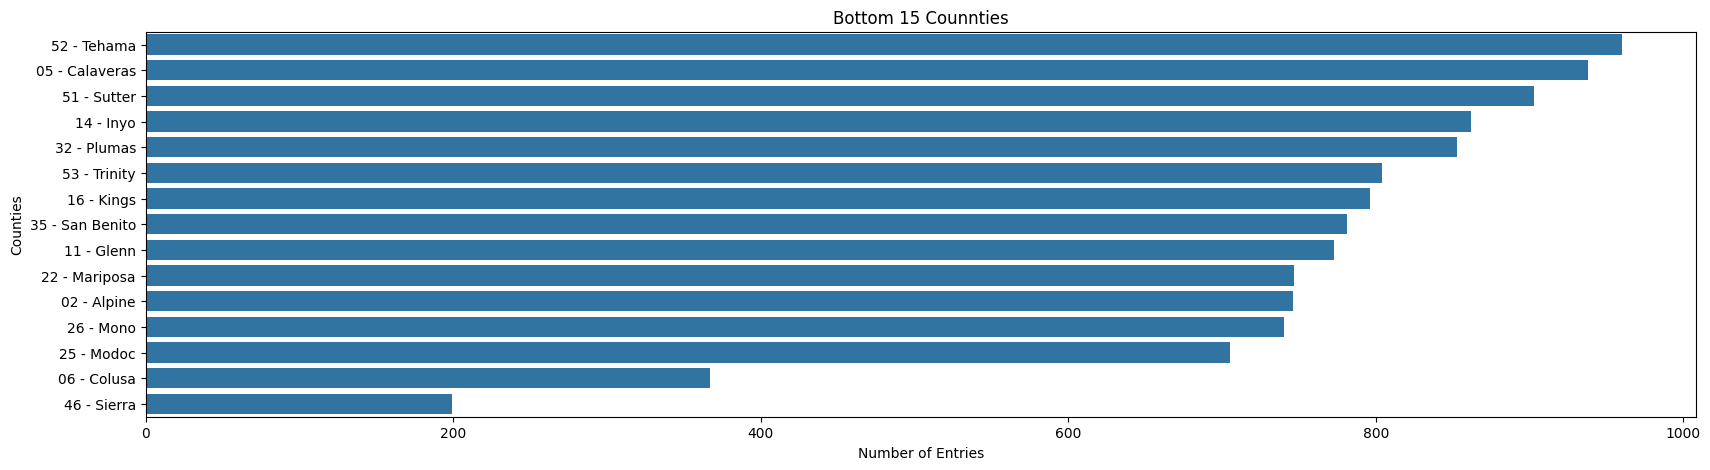

,count
County,
52 - Tehama,960
05 - Calaveras,938
51 - Sutter,903
14 - Inyo,862
32 - Plumas,853
53 - Trinity,804
16 - Kings,796
35 - San Benito,781
11 - Glenn,773


In [56]:
# Univariate Analysis 1: Bottom 15 Counties
plt.figure(figsize=(20, 5))
bottom_counties = df_clean['County'].value_counts().tail(15)
sns.barplot(x=bottom_counties.values, y=bottom_counties.index)
plt.title('Bottom 15 Counnties')
plt.xlabel('Number of Entries')
plt.ylabel('Counties')
plt.show()

bottom_counties

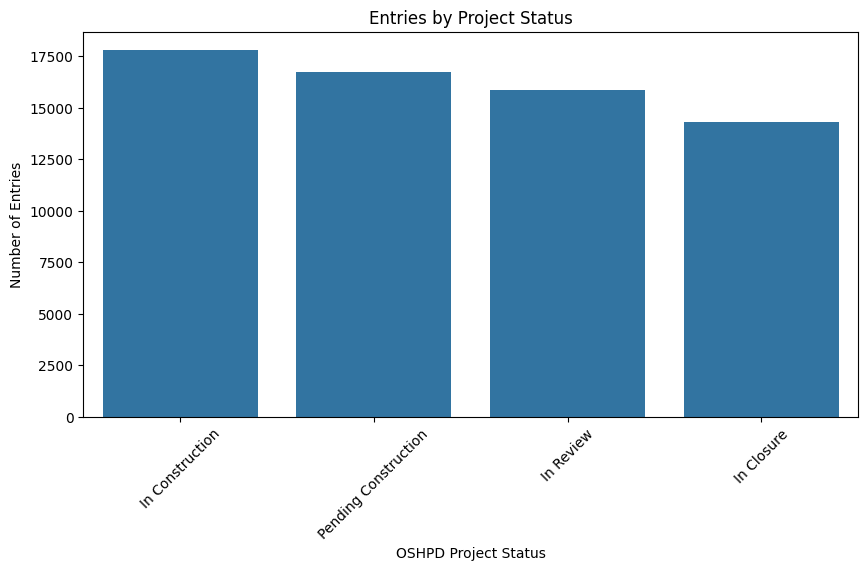

In [58]:
# Univariate Analysis 2: OSHPD Project Status
plt.figure(figsize=(10, 5))
status_counts = df_clean['OSHPD Project Status'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title('Entries by Project Status')
plt.xlabel('OSHPD Project Status')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)
plt.show()

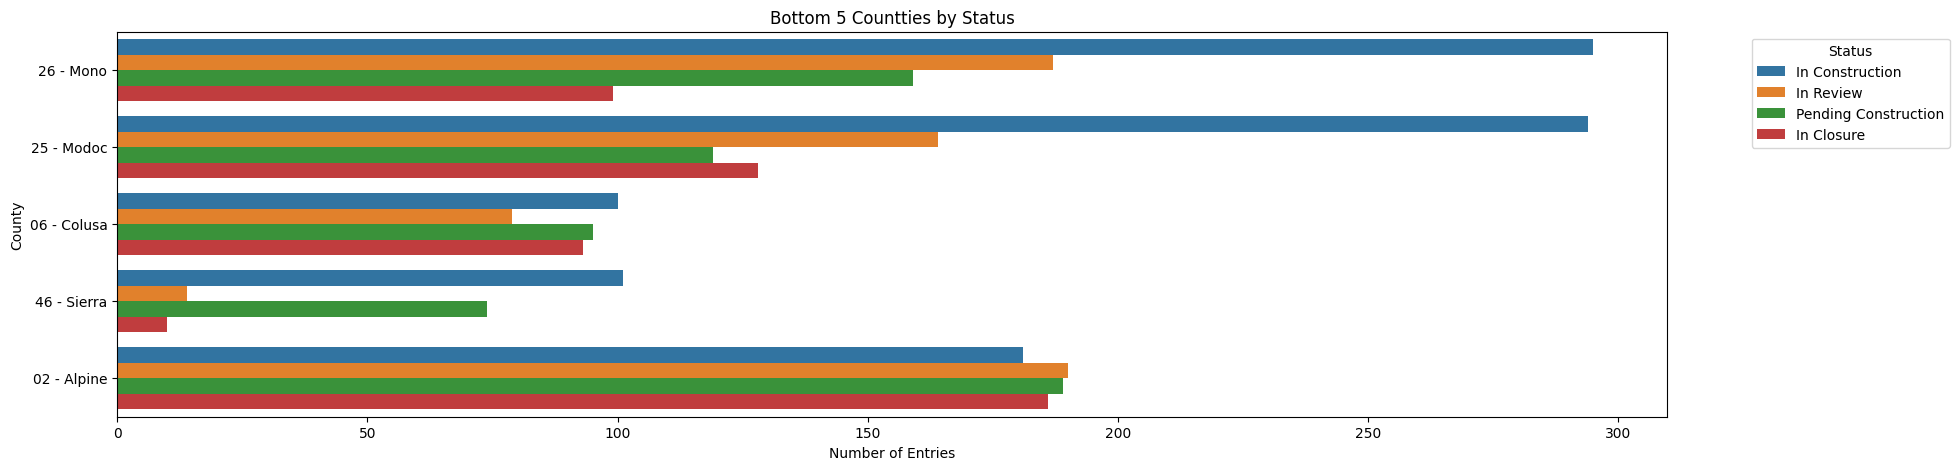

OSHPD Project Status,In Closure,In Construction,In Review,Pending Construction
County,,,,
02 - Alpine,186,181,190,189
06 - Colusa,93,100,79,95
25 - Modoc,128,294,164,119
26 - Mono,99,295,187,159
46 - Sierra,10,101,14,74


In [60]:
# Bivariate Analysis 1: Bottom counties by status
bottom_5_county = df_clean['County'].value_counts().tail(5).index
county_status = df_clean[df_clean['County'].isin(bottom_5_county)]

plt.figure(figsize=(20, 5))
sns.countplot(data=county_status, y='County', hue='OSHPD Project Status')
plt.title('Bottom 5 Countties by Status')
plt.xlabel('Number of Entries')
plt.ylabel('County')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

pd.crosstab(county_status['County'], county_status['OSHPD Project Status'])

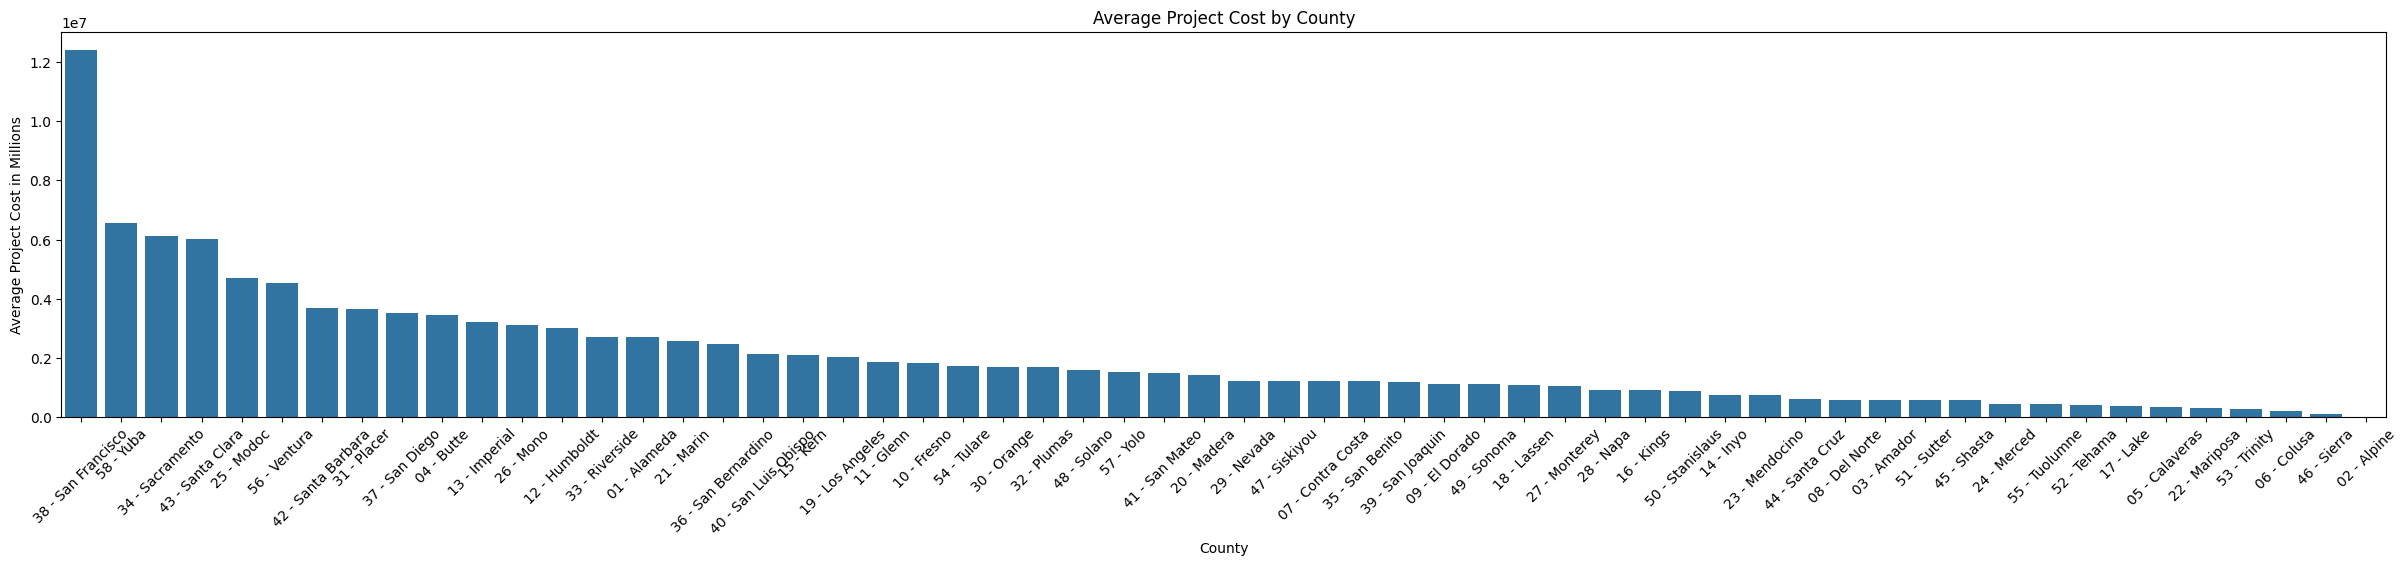

,Average Project Cost
County,
38 - San Francisco,1.240681e+07
58 - Yuba,6.560044e+06
34 - Sacramento,6.116582e+06
43 - Santa Clara,6.010357e+06
25 - Modoc,4.714118e+06
56 - Ventura,4.542229e+06
42 - Santa Barbara,3.694504e+06
31 - Placer,3.651281e+06
37 - San Diego,3.529500e+06


In [38]:
# Bivariate Analysis 2: Average Project Cost by County
if 'Average Project Cost' in df_clean.columns:
    cost_by_county = df_clean.groupby('County')['Average Project Cost'].mean().sort_values(ascending=False)

    plt.figure(figsize=(30, 5))
    sns.barplot(x=cost_by_county.index, y=cost_by_county.values)
    plt.title('Average Project Cost by County')
    plt.xlabel('County')
    plt.ylabel('Average Project Cost in Millions')
    plt.xticks(rotation=45)
    plt.show()

    display(cost_by_county)
else:
    print("Average Project Cost could not be calculated because Total Costs of OSHPD Projects or Number of OSHPD Projects is missing.")

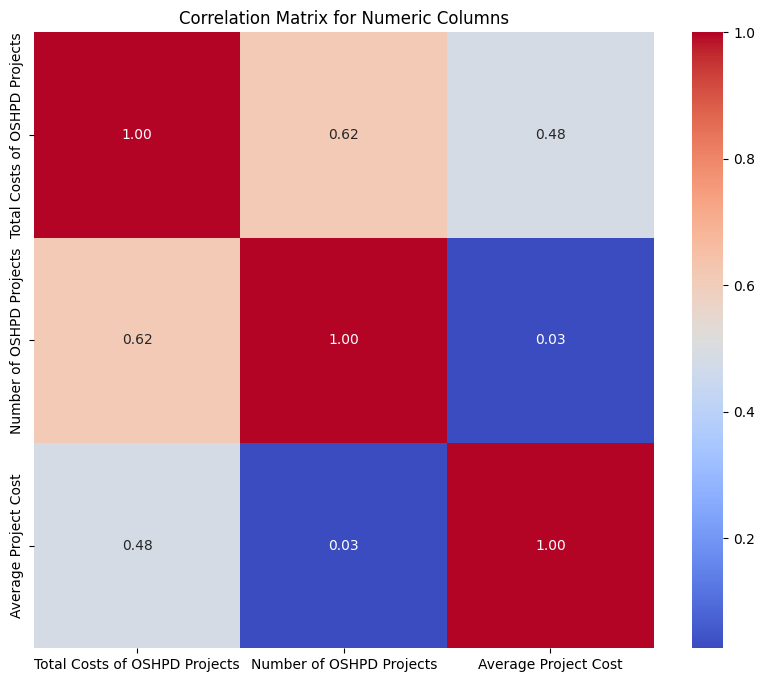

,Total Costs of OSHPD Projects,Number of OSHPD Projects,Average Project Cost
Total Costs of OSHPD Projects,1.000000,0.615527,0.482504
Number of OSHPD Projects,0.615527,1.000000,0.025647
Average Project Cost,0.482504,0.025647,1.000000


In [48]:
# Select numeric columns for correlation
numeric_df = df_clean.select_dtypes(include=[np.number])

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Numeric Columns')
plt.show()

corr_matrix

In [61]:
summary_lines = []

summary_lines.append(f"The dataset contains {df.shape[0]:,} rows and {df.shape[1]:,} columns before cleaning.")
summary_lines.append(f"The original dataset had {total_missing:,} missing values across all columns.")
summary_lines.append(f"After imputation, the cleaned dataset has {df_clean.isnull().sum().sum():,} missing values.")

if 'County' in df_clean.columns:
    bottom_county = df_clean['County'].value_counts().idxmax()
    bottom_county_count = df_clean['County'].value_counts().min()
    summary_lines.append(f"The most common County is '{bottom_county}' with {bottom_county_count:,} collections.")

if 'Collection of Counties' in df_clean.columns:
    top_collection = df_clean['Collection of Counties'].value_counts().idxmax()
    top_collection_count = df_clean['Collection of Counties'].value_counts().max()
    summary_lines.append(f"The Collection of Counties with the highest number of entries is '{top_collection}' with {top_collection_count:,} collections.")

if 'OSHPD Project Status' in df_clean.columns:
    top_status = df_clean['OSHPD Project Status'].value_counts().idxmax()
    summary_lines.append(f"The most frequent collection status is '{top_status}'.")

if 'Average Project Costs' in df_clean.columns:
    avg_close = df_clean['Average Project Cost'].mean()
    median_close = df_clean['Average Project Cost'].median()
    summary_lines.append(f"The average Project Cost is approximately {avg_close:.2f} dollars, while the median Project Cost is approximately {median_close:.2f} dollars.")

summary_lines.append("The analysis shows which counties and OSHPD collection agencies generate the lowest collection rates, helping California healthcare construction teams understand where there is a lack of resources.")
summary_lines.append("The cleaned dataset is now suitable for further data collection to understand more correlation between healthcare construction costs and local communties.")
summary_lines.append("To enhance the dataset, counties should collect more information on building types, use cases for the building, and who is the largest investor to these projects.")

print("FINAL FINDINGS SUMMARY")
print("-" * 60)
for line in summary_lines:
    print("• " + line)

FINAL FINDINGS SUMMARY
------------------------------------------------------------
• The dataset contains 64,721 rows and 6 columns before cleaning.
• The original dataset had 48,021 missing values across all columns.
• After imputation, the cleaned dataset has 0 missing values.
• The most common County is '19 - Los Angeles' with 199 collections.
• The Collection of Counties with the highest number of entries is 'Bay Area Counties' with 55,757 collections.
• The most frequent collection status is 'In Construction'.
• The analysis shows which counties and OSHPD collection agencies generate the lowest collection rates, helping California healthcare construction teams understand where there is a lack of resources.
• The cleaned dataset is now suitable for further data collection to understand more correlation between healthcare construction costs and local communties.
• To enhance the dataset, counties should collect more information on building types, use cases for the building, and who